# **Importing Libraries**
1. Amazon Dataset--From Kaggle

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from matplotlib.ticker import FuncFormatter
print("✅ All dependencies successfully imported!")

✅ All dependencies successfully imported!


# Read File

In [ ]:
df = pd.read_csv('/content/amazon.csv', engine='python', on_bad_lines='skip')
print(df.head())

   product_id                                       product_name  \
0  B07JW9H4J1  Wayona Nylon Braided USB to Lightning Fast Cha...   
1  B098NS6PVG  Ambrane Unbreakable 60W / 3A Fast Charging 1.5...   
2  B096MSW6CT  Sounce Fast Phone Charging Cable & Data Sync U...   
3  B08HDJ86NZ  boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...   
4  B08CF3B7N1  Portronics Konnect L 1.2M Fast Charging 3A 8 P...   

                                            category discounted_price  \
0  Computers&Accessories|Accessories&Peripherals|...             ₹399   
1  Computers&Accessories|Accessories&Peripherals|...             ₹199   
2  Computers&Accessories|Accessories&Peripherals|...             ₹199   
3  Computers&Accessories|Accessories&Peripherals|...             ₹329   
4  Computers&Accessories|Accessories&Peripherals|...             ₹154   

  actual_price discount_percentage rating rating_count  \
0       ₹1,099                 64%    4.2       24,269   
1         ₹349                 43%  

# Inspection of Dataset


In [ ]:
df.shape

(2308, 16)

In [ ]:
df.head(5)

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [ ]:
df.columns

Index(['product_id', 'product_name', 'category', 'discounted_price',
       'actual_price', 'discount_percentage', 'rating', 'rating_count',
       'about_product', 'user_id', 'user_name', 'review_id', 'review_title',
       'review_content', 'img_link', 'product_link'],
      dtype='object')

# custom cleaning function
*   designed to clean multiple columns at once




In [ ]:
def convert(value):
    if pd.isna(value):
        return value
    # Ensure value is treated as a string before replacement
    value = str(value).replace("₹", "").replace("%", "").replace(",", "").strip()
    return pd.to_numeric(value, errors="coerce")
cols = [
    'discounted_price',
    'actual_price',
    'discount_percentage',
    'rating',
    'rating_count'
]
# Apply conversion to selected columns, handling existing numeric types
for col in cols:
    # Only apply convert if the column is not already numeric or contains strings
    if df[col].dtype == 'object' or df[col].apply(lambda x: isinstance(x, str)).any():
        df[col] = df[col].apply(convert)

# Special handling for 'rating_count' nulls after initial conversion
df['rating_count'] = df['rating_count'].fillna(df['rating_count'].median())

In [ ]:
df.tail()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
2303,B08L7J3T31,Noir Aqua - 5pcs PP Spun Filter + 1 Spanner | ...,Home&Kitchen|Kitchen&HomeAppliances|WaterPurif...,379.0,919.0,59.0,4.0,1090.0,SUPREME QUALITY 90 GRAM 3 LAYER THIK PP SPUN F...,"AHITFY6AHALOFOHOZEOC6XBP4FEA,AFRABBODZJZQB6Z4U...","Prabha ds,Raghuram bk,Real Deal,Amazon Custome...","R3G3XFHPBFF0E8,R3C0BZCD32EIGW,R2EBVBCN9QPD9R,R...","Received the product without spanner,Excellent...","I received product without spanner,Excellent p...",https://m.media-amazon.com/images/I/41fDdRtjfx...,https://www.amazon.in/Noir-Aqua-Spanner-Purifi...
2304,B01M6453MB,Prestige Delight PRWO Electric Rice Cooker (1 ...,Home&Kitchen|Kitchen&HomeAppliances|SmallKitch...,2280.0,3045.0,25.0,4.1,4118.0,"230 Volts, 400 watts, 1 Year","AFG5FM3NEMOL6BNFRV2NK5FNJCHQ,AGEINTRN6Z563RMLH...","Manu Bhai,Naveenpittu,Evatira Sangma,JAGANNADH...","R3DDL2UPKQ2CK9,R2SYYU1OATVIU5,R1VM993161IYRW,R...","ok,everything was good couldn't return bcoz I ...","ok,got everything as mentioned but the measuri...",https://m.media-amazon.com/images/I/41gzDxk4+k...,https://www.amazon.in/Prestige-Delight-PRWO-1-...
2305,B009P2LIL4,Bajaj Majesty RX10 2000 Watts Heat Convector R...,"Home&Kitchen|Heating,Cooling&AirQuality|RoomHe...",2219.0,3080.0,28.0,3.6,468.0,International design and styling|Two heat sett...,"AGVPWCMAHYQWJOQKMUJN4DW3KM5Q,AF4Q3E66MY4SR7YQZ...","Nehal Desai,Danish Parwez,Amazon Customer,Amaz...","R1TLRJVW4STY5I,R2O455KRN493R1,R3Q5MVGBRIAS2G,R...","very good,Work but front melt after 2 month,Go...","plastic but cool body ,u have to find sturdy s...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Bajaj-RX-10-2000-Watt-Co...
2306,B00J5DYCCA,Havells Ventil Air DSP 230mm Exhaust Fan (Pist...,"Home&Kitchen|Heating,Cooling&AirQuality|Fans|E...",1399.0,1890.0,26.0,4.0,8031.0,Fan sweep area: 230 MM ; Noise level: (40 - 45...,"AF2JQCLSCY3QJATWUNNHUSVUPNQQ,AFDMLUXC5LS5RXDJS...","Shubham Dubey,E.GURUBARAN,Mayank S.,eusuf khan...","R39Q2Y79MM9SWK,R3079BG1NIH6MB,R29A31ZELTZNJM,R...","Fan Speed is slow,Good quality,Good product,go...",I have installed this in my kitchen working fi...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Havells-Ventilair-230mm-...
2307,B01486F4G6,Borosil Jumbo 1000-Watt Grill Sandwich Maker (...,Home&Kitchen|Kitchen&HomeAppliances|SmallKitch...,2863.0,3690.0,22.0,4.3,6987.0,"Brand-Borosil, Specification â€“ 23V ~ 5Hz;1 W...","AFGW5PT3R6ZAVQR4Y5MWVAKBZAYA,AG7QNJ2SCS5VS5VYY...","Rajib,Ajay B,Vikas Kahol,PARDEEP,Anindya Prama...","R20RBRZ0WEUJT9,ROKIFK9R2ISSE,R30EEG2FNJSN5I,R2...","Works perfect,Ok good product,Nice Product. Re...",It does it job perfectly..only issue is temp c...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Borosil-Jumbo-1000-Watt-...


In [ ]:
df.columns.tolist()

['product_id',
 'product_name',
 'category',
 'discounted_price',
 'actual_price',
 'discount_percentage',
 'rating',
 'rating_count',
 'about_product',
 'user_id',
 'user_name',
 'review_id',
 'review_title',
 'review_content',
 'img_link',
 'product_link']

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2308 entries, 0 to 2307
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_id           2308 non-null   object 
 1   product_name         2308 non-null   object 
 2   category             2308 non-null   object 
 3   discounted_price     2307 non-null   float64
 4   actual_price         2307 non-null   float64
 5   discount_percentage  2307 non-null   float64
 6   rating               2305 non-null   float64
 7   rating_count         2308 non-null   float64
 8   about_product        2308 non-null   object 
 9   user_id              2308 non-null   object 
 10  user_name            2308 non-null   object 
 11  review_id            2308 non-null   object 
 12  review_title         2308 non-null   object 
 13  review_content       2308 non-null   object 
 14  img_link             2308 non-null   object 
 15  product_link         2308 non-null   o

In [ ]:
df.dtypes

,0
product_id,object
product_name,object
category,object
discounted_price,float64
actual_price,float64
discount_percentage,float64
rating,float64
rating_count,float64
about_product,object
user_id,object


In [ ]:
df[['discounted_price', 'actual_price', 'discount_percentage',
    'rating', 'rating_count']].head(10)

,discounted_price,actual_price,discount_percentage,rating,rating_count
0,399.00,1099.0,64.0,4.2,24269.0
1,199.00,349.0,43.0,4.0,43994.0
2,199.00,1899.0,90.0,3.9,7928.0
3,329.00,699.0,53.0,4.2,94363.0
4,154.00,399.0,61.0,4.2,16905.0
5,149.00,1000.0,85.0,3.9,24871.0
6,176.63,499.0,65.0,4.1,15188.0
7,229.00,299.0,23.0,4.3,30411.0
8,499.00,999.0,50.0,4.2,179691.0
9,199.00,299.0,33.0,4.0,43994.0


In [ ]:
df.describe()

,discounted_price,actual_price,discount_percentage,rating,rating_count
count,2307.000000,2307.000000,2307.000000,2305.00000,2308.000000
mean,2644.100074,4707.473879,46.302124,4.09410,16370.134749
std,5874.792355,9439.173588,21.592240,0.29855,38397.592699
min,39.000000,39.000000,0.000000,2.00000,2.000000
25%,348.000000,855.500000,31.000000,3.90000,1173.000000
50%,879.000000,1699.000000,48.000000,4.10000,4768.000000
75%,1999.000000,3999.000000,62.000000,4.30000,15149.750000
max,77990.000000,139900.000000,94.000000,5.00000,426973.000000


In [ ]:
df.describe(include='all')

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
count,2308,2308,2308,2307.000000,2307.000000,2307.000000,2305.00000,2308.000000,2308,2308,2308,2308,2308,2308,2308,2308
unique,1351,1337,212,NaN,NaN,NaN,NaN,NaN,1293,1194,1194,1194,1194,1212,1412,1465
top,B09NHVCHS9,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...",Computers&Accessories|Accessories&Peripherals|...,NaN,NaN,NaN,NaN,NaN,[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AHIKJUDTVJ4T6DV6IUGFYZ5LXMPA,AE55KTFVNXYFD5FPY...","$@|\|TO$|-|,Sethu madhav,Akash Thakur,Burger P...","R3F4T5TRYPTMIG,R3DQIEC603E7AY,R1O4Z15FD40PV5,R...","Worked on iPhone 7 and didn’t work on XR,Good ...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Borosil-Jumbo-1000-Watt-...
freq,4,5,278,NaN,NaN,NaN,NaN,NaN,8,11,11,11,11,8,4,2
mean,NaN,NaN,NaN,2644.100074,4707.473879,46.302124,4.09410,16370.134749,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,5874.792355,9439.173588,21.592240,0.29855,38397.592699,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,39.000000,39.000000,0.000000,2.00000,2.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,348.000000,855.500000,31.000000,3.90000,1173.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,879.000000,1699.000000,48.000000,4.10000,4768.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,1999.000000,3999.000000,62.000000,4.30000,15149.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# 1.   checking for the null values



In [ ]:

df.isnull().sum()

,0
product_id,0
product_name,0
category,0
discounted_price,1
actual_price,1
discount_percentage,1
rating,3
rating_count,0
about_product,0
user_id,0


In [ ]:
# Drop rows with any remaining null values in the relevant columns
df.dropna(subset=['discounted_price', 'actual_price', 'discount_percentage', 'rating'], inplace=True)

# Verify that there are no more null values
print(df.isnull().sum())

product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           0
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64


In [ ]:
df.describe()

,discounted_price,actual_price,discount_percentage,rating,rating_count
count,2305.000000,2305.000000,2305.000000,2305.00000,2305.000000
mean,2644.573046,4709.390126,46.328416,4.09410,16388.511497
std,5877.319663,9443.045194,21.583136,0.29855,38419.146767
min,39.000000,39.000000,0.000000,2.00000,2.000000
25%,348.000000,850.000000,31.000000,3.90000,1173.000000
50%,873.000000,1695.000000,48.000000,4.10000,4768.000000
75%,1999.000000,3999.000000,62.000000,4.30000,15188.000000
max,77990.000000,139900.000000,94.000000,5.00000,426973.000000


# **feature engineering and uniqueness analysis**

In [ ]:
df["main_category"] = df["category"].str.split("|").str[0]

In [ ]:
df["product_id"].nunique()

1349

In [ ]:
df["main_category"].nunique()

9

# **Product Distribution by Main Category**

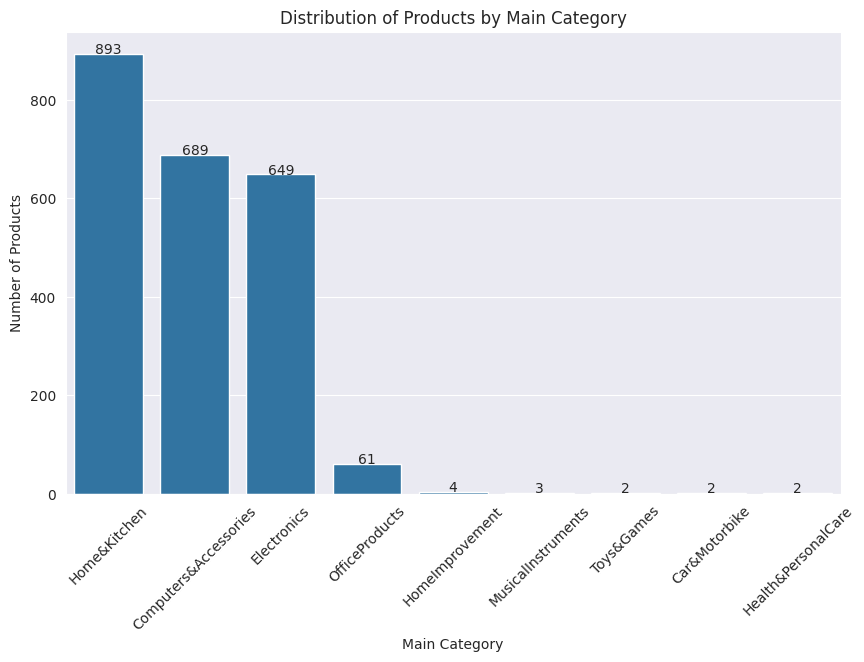

In [ ]:
# Count products in each main category
category_counts = df["main_category"].value_counts()
# Create the plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x=category_counts.index,
    y=category_counts.values
)
# Add title and labels
plt.title("Distribution of Products by Main Category")
plt.xlabel("Main Category")
plt.ylabel("Number of Products")
# Rotate category names
plt.xticks(rotation=45)
# Add values on top of each bar
for i, value in enumerate(category_counts.values):
    plt.text(i, value, str(value), ha="center")
plt.show()

In [ ]:
#pivot for better understanding for discounted price
pivot = pd.pivot_table(
    df,
    values="discounted_price",
    index="main_category",
    aggfunc=["mean", "max", "min"]
)

pivot.round(2)

,mean,max,min
,discounted_price,discounted_price,discounted_price
main_category,,,
Car&Motorbike,2339.00,2339.0,2339.0
Computers&Accessories,984.16,37247.0,39.0
Electronics,5092.80,77990.0,79.0
Health&PersonalCare,899.00,899.0,899.0
Home&Kitchen,2333.60,42990.0,79.0
HomeImprovement,337.00,425.0,249.0
MusicalInstruments,584.67,798.0,478.0
OfficeProducts,305.70,1399.0,50.0


# **average discounted price by category**

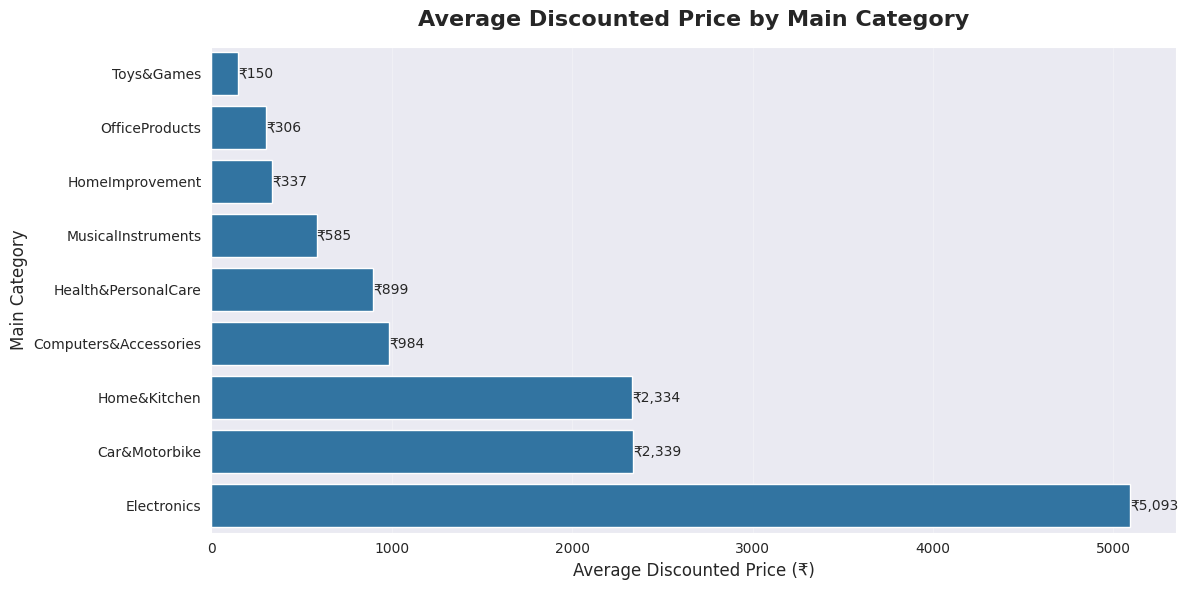

In [ ]:
# Calculate average discounted price by main category
average_price = (
    df.groupby("main_category")["discounted_price"]
    .mean()
    .sort_values(ascending=True)
)

# Create figure
plt.figure(figsize=(12, 6))

# Create bar chart
ax = sns.barplot(
    x=average_price.values,
    y=average_price.index
)

# Add value labels to each bar
for i, value in enumerate(average_price.values):
    plt.text(
        value,
        i,
        f"₹{value:,.0f}",
        va="center",
        ha="left"
    )

# Add title and labels
plt.title(
    "Average Discounted Price by Main Category",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Average Discounted Price (₹)", fontsize=12)
plt.ylabel("Main Category", fontsize=12)

# Add grid for better readability
plt.grid(axis="x", alpha=0.3)

# Adjust layout
plt.tight_layout()

plt.show()

In [ ]:
pivot_rating = pd.pivot_table(
    df,
    values="rating",
    index="main_category",
    aggfunc=["mean", "count"]
)

pivot_rating

,mean,count
,rating,rating
main_category,,
Car&Motorbike,3.800000,2
Computers&Accessories,4.157620,689
Electronics,4.080277,649
Health&PersonalCare,4.000000,2
Home&Kitchen,4.040873,893
HomeImprovement,4.250000,4
MusicalInstruments,3.866667,3
OfficeProducts,4.309836,61


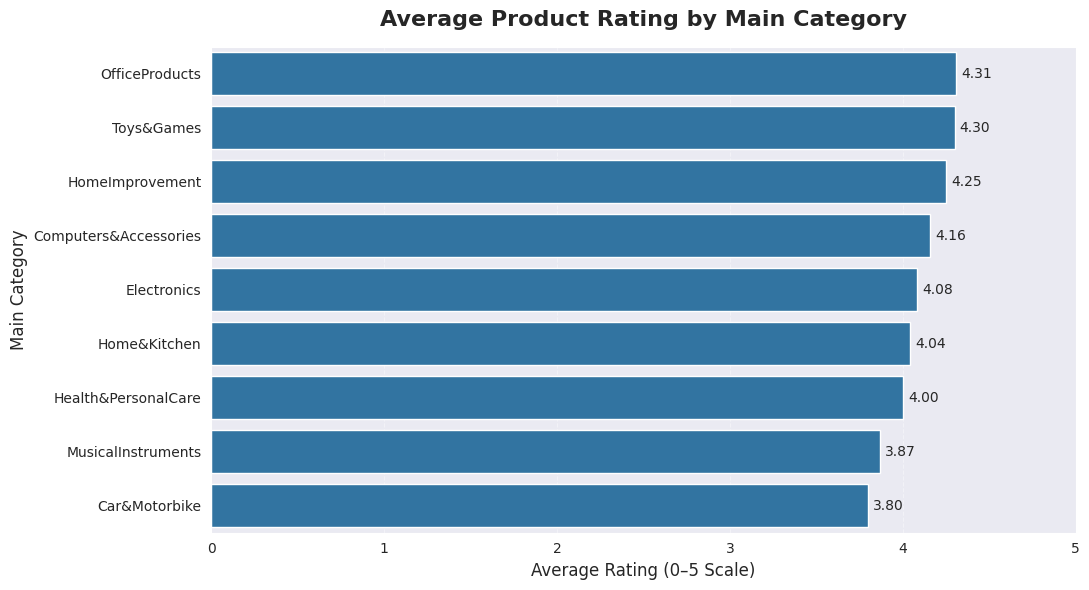

In [ ]:
# Extract average rating and sort from highest to lowest
average_rating = (
    pivot_rating["mean"]["rating"]
    .sort_values(ascending=False)
)
plt.figure(figsize=(11, 6))
ax = sns.barplot(
    x=average_rating.values,
    y=average_rating.index
)
for i, value in enumerate(average_rating.values):
    ax.text(
        value + 0.03,
        i,
        f"{value:.2f}",
        va="center",
        fontsize=10
    )

# Add title and axis labels
plt.title(
    "Average Product Rating by Main Category",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Average Rating (0–5 Scale)", fontsize=12)
plt.ylabel("Main Category", fontsize=12)

# Set rating scale
plt.xlim(0, 5)

# Add light grid for readability
plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.4
)

# Improve spacing
plt.tight_layout()

# Display the chart
plt.show()

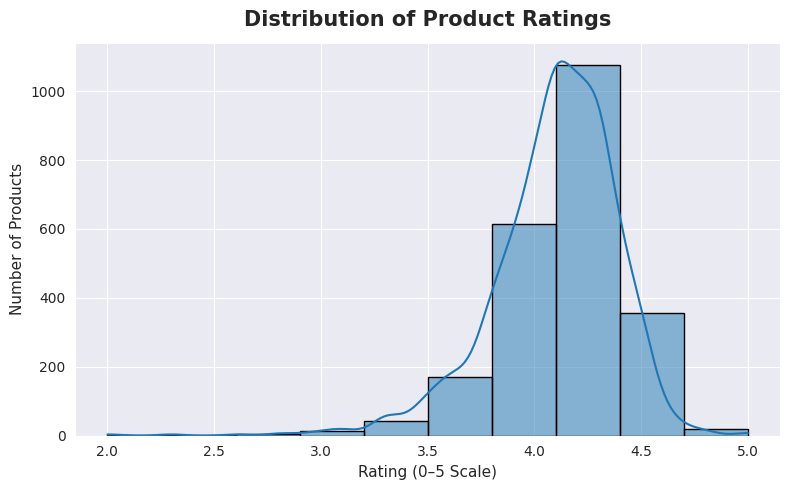

In [ ]:
# Set the visualization style
sns.set_style("darkgrid")

# Create the figure
plt.figure(figsize=(8, 5))

# Create histogram
sns.histplot(
    data=df,
    x="rating",
    bins=10,
    kde=True,
    edgecolor="black"
)

# Add title and labels
plt.title(
    "Distribution of Product Ratings",
    fontsize=15,
    fontweight="bold",
    pad=12
)

plt.xlabel("Rating (0–5 Scale)", fontsize=11)
plt.ylabel("Number of Products", fontsize=11)

# Improve layout
plt.tight_layout()

# Display the plot
plt.show()

#The Amazon products in this dataset generally have high ratings, with the majority concentrated around 4.0–4.5, indicating overall positive customer feedback.


# **Coorelation Heatmap**

In [ ]:
corr = df[
    [
        "discounted_price",
        "actual_price",
        "discount_percentage",
        "rating",
        "rating_count"
    ]
].corr()

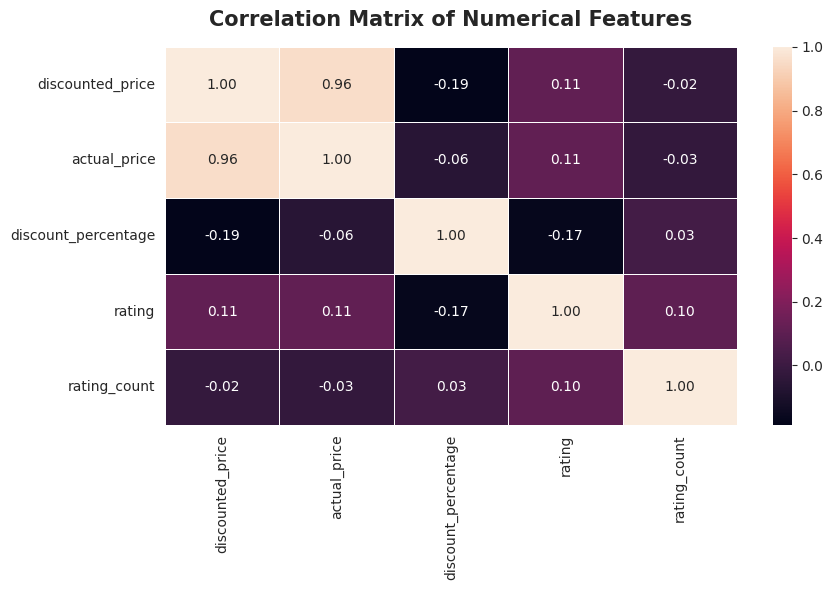

In [ ]:
# Create correlation matrix
corr = df[
    [
        "discounted_price",
        "actual_price",
        "discount_percentage",
        "rating",
        "rating_count"
    ]
].corr()

# Create figure
plt.figure(figsize=(9, 6))

# Create heatmap
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

# Add title
plt.title(
    "Correlation Matrix of Numerical Features",
    fontsize=15,
    fontweight="bold",
    pad=15
)

plt.tight_layout()

plt.show()

#The strongest relationship in the dataset is between actual price and discounted price. Most other variables show weak correlations, indicating that product ratings and rating counts are not strongly dependent on price or discount percentage.

#Actual Price Vs Discounted Price

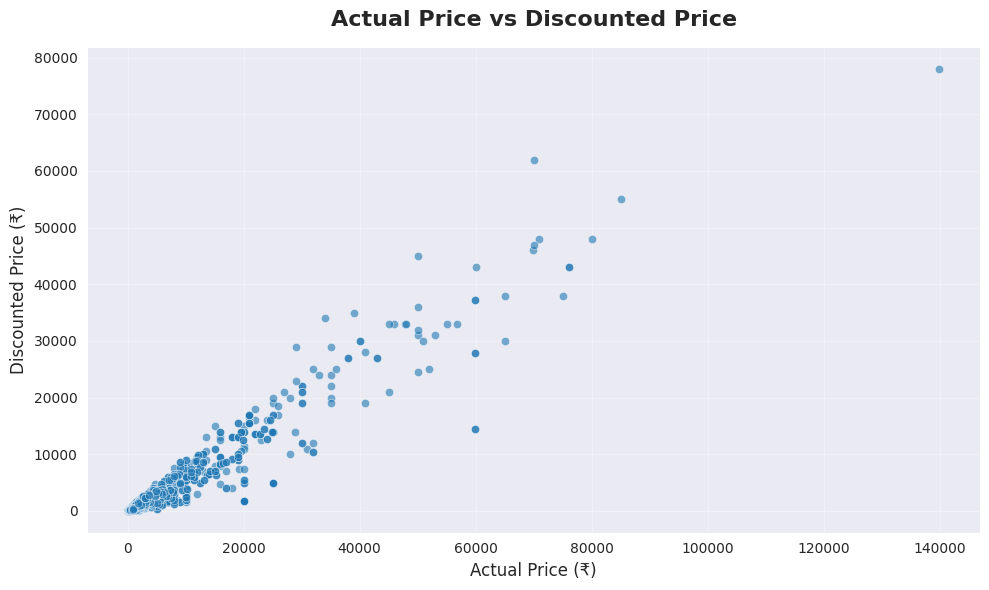

In [ ]:
# Create figure
plt.figure(figsize=(10, 6))

# Create scatter plot
sns.scatterplot(
    data=df,
    x="actual_price",
    y="discounted_price",
    alpha=0.6
)

# Add title and labels
plt.title(
    "Actual Price vs Discounted Price",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Actual Price (₹)", fontsize=12)
plt.ylabel("Discounted Price (₹)", fontsize=12)

# Add grid
plt.grid(alpha=0.3)

# Improve spacing
plt.tight_layout()

# Display plot
plt.show()

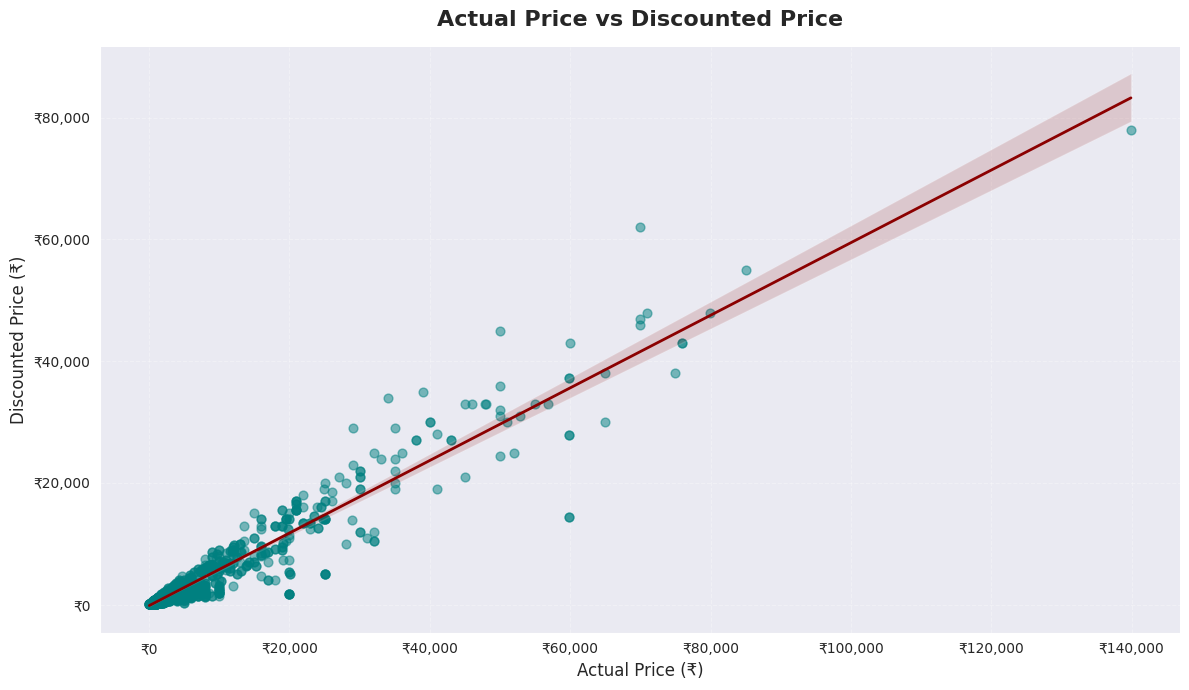

In [ ]:
# Create figure
plt.figure(figsize=(12, 7))
# Scatter plot with regression line
sns.regplot(
    data=df,
    x="actual_price",
    y="discounted_price",
    scatter_kws={
        "alpha": 0.5,
        "s": 40,
        "color": "teal"
    },
    line_kws={
        "color": "darkred",
        "linewidth": 2
    }
)
# Format axes as Indian currency
formatter = FuncFormatter(lambda x, pos: f"₹{x:,.0f}")
plt.gca().xaxis.set_major_formatter(formatter)
plt.gca().yaxis.set_major_formatter(formatter)
# Title and labels
plt.title(
    "Actual Price vs Discounted Price",
    fontsize=16,
    fontweight="bold",
    pad=15
)
plt.xlabel("Actual Price (₹)", fontsize=12)
plt.ylabel("Discounted Price (₹)", fontsize=12)
# Add subtle grid
plt.grid(axis="both", linestyle="--", alpha=0.3)
# Remove unnecessary borders
sns.despine()
# Adjust layout
plt.tight_layout()
# Show plot
plt.show()

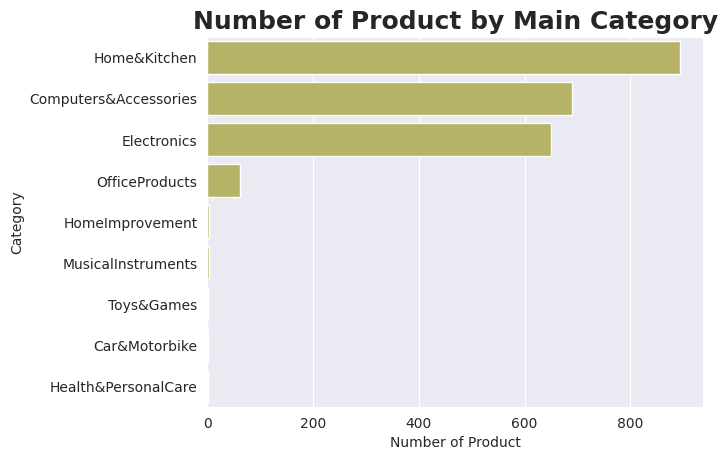

In [ ]:
plt.Figure(figsize=(12,6))
sns.countplot(data=df,y="main_category",color="#c3be5a",order=df["main_category"].value_counts().index)
plt.title("Number of Product by Main Category",fontsize=18,fontweight="bold")
plt.xlabel("Number of Product")
plt.ylabel("Category")
plt.show()

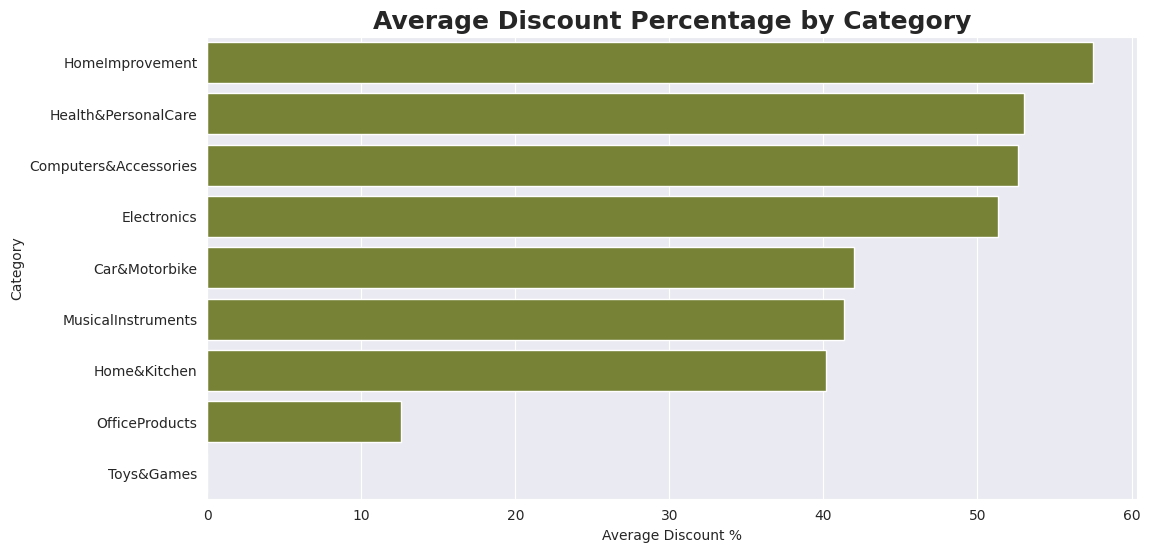

In [ ]:
category_discount = (df.groupby("main_category")["discount_percentage"].mean().sort_values(ascending=False))
plt.figure(figsize=(12, 6))
sns.barplot(x=category_discount.values,y=category_discount.index,color="#808e2a")

plt.title("Average Discount Percentage by Category",fontsize=18,fontweight="bold")
plt.xlabel("Average Discount %")
plt.ylabel("Category")

plt.show()

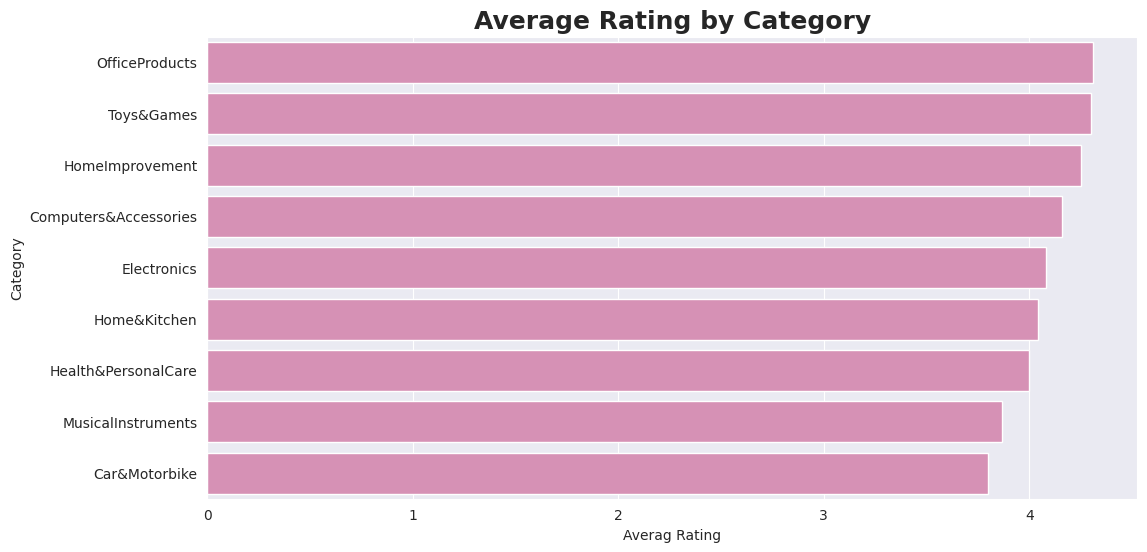

In [ ]:
category_rating = (df.groupby("main_category")["rating"].mean().sort_values(ascending=False))
plt.figure(figsize=(12, 6))
sns.barplot(x=category_rating.values,y=category_rating.index,color="#E285B5")

plt.title("Average Rating by Category",fontsize=18,fontweight="bold")
plt.xlabel("Averag Rating")
plt.ylabel("Category")

plt.show()

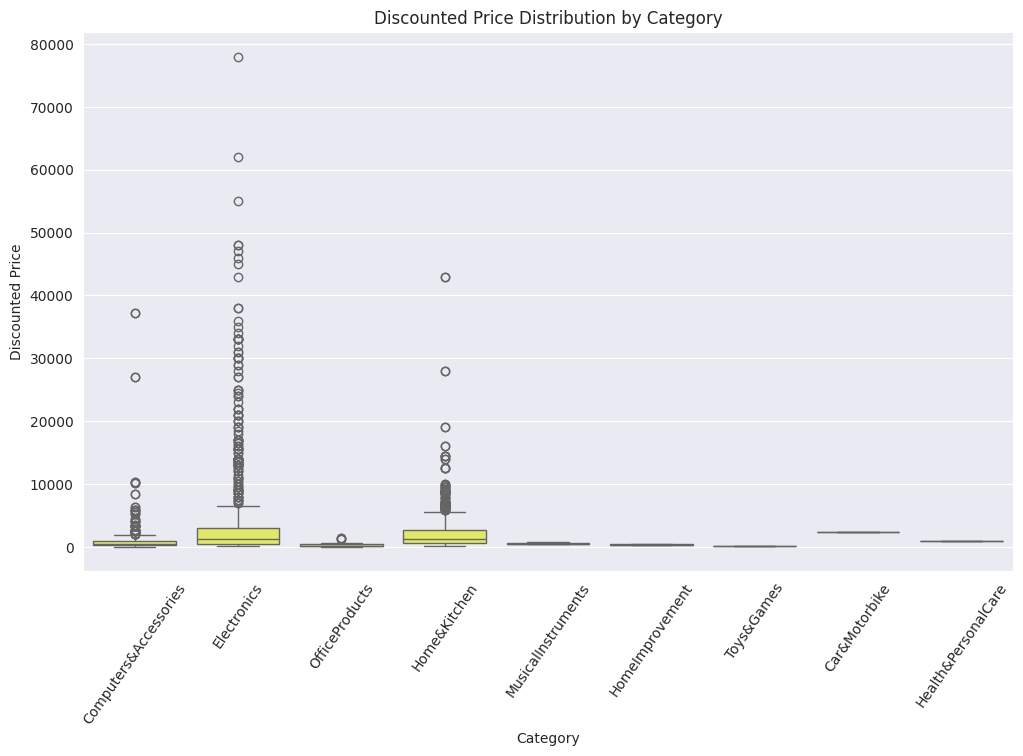

In [ ]:
plt.figure(figsize=(12, 7))
sns.boxplot(data=df,x="main_category",y="discounted_price",color="#f3ff50")

plt.title("Discounted Price Distribution by Category")
plt.xlabel("Category")
plt.ylabel("Discounted Price")

plt.xticks(rotation=55)

plt.show()

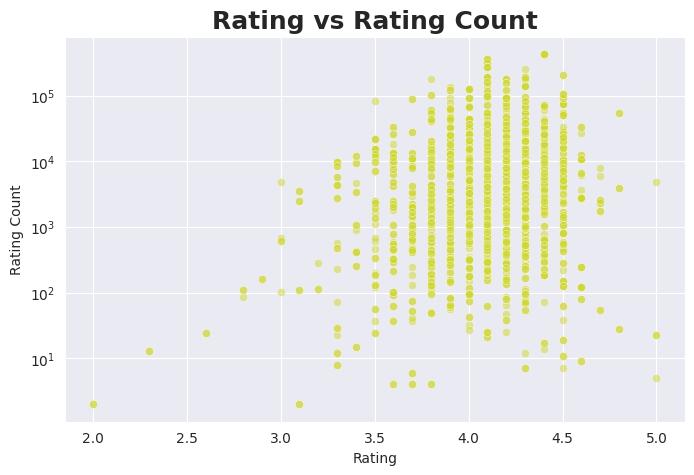

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,x="rating",y="rating_count",alpha=0.5,color="#cfd736")
plt.yscale("log")
plt.title("Rating vs Rating Count",fontsize=18,fontweight="bold")
plt.xlabel("Rating")
plt.ylabel("Rating Count")
plt.show()

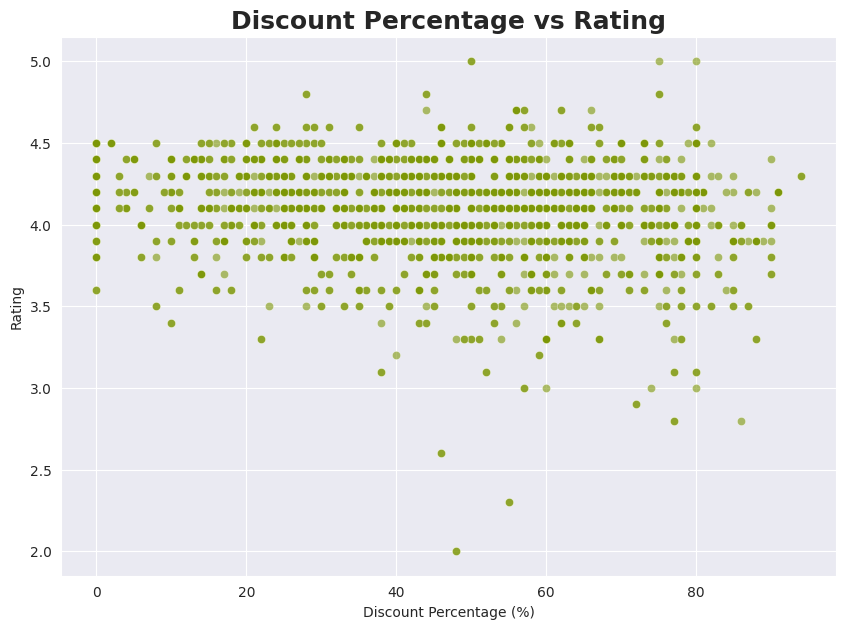

In [ ]:
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df,x="discount_percentage",y="rating",alpha=0.6,color="#7d9707")
plt.title("Discount Percentage vs Rating",fontsize=18,fontweight="bold")
plt.xlabel("Discount Percentage (%)")
plt.ylabel("Rating")
plt.show()

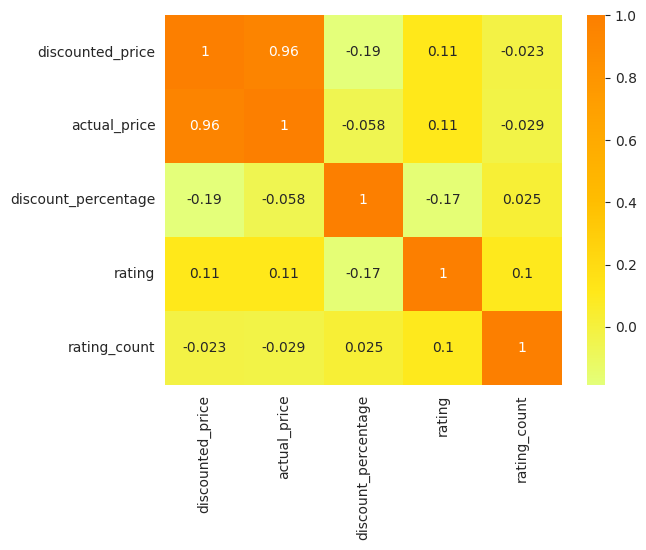

In [ ]:
plt.Figure(figsize=(10,7))
sns.heatmap(corr,annot=True,cmap="Wistia")
plt.show()

In [ ]:
import plotly.express as px

In [ ]:
fig = px.scatter(
    df,
    x="discount_percentage",
    y="rating",
    size="rating_count",
    hover_name="product_name",
    color="main_category",
    title="Discount Percentage vs Product Rating",
    labels={
        "discount_percentage": "Discount Percentage",
        "rating": "Product Rating",
        "rating_count": "Number of Ratings",
        "main_category": "Main Category"
    },
    template="plotly_white",
    size_max=40
)

fig.update_layout(
    title_font_size=20,
    title_x=0.5,
    width=1000,
    height=600
)

fig.show()

In [ ]:
# Calculate average discounted price for each category
category_price = (
    df.groupby("main_category")["discounted_price"]
    .mean()
    .reset_index()
    .sort_values(
        "discounted_price",
        ascending=False
    )
)

# Create interactive bar chart
fig = px.bar(
    category_price,
    x="main_category",
    y="discounted_price",
    title="Average Discounted Price by Main Category",
    labels={
        "main_category": "Main Category",
        "discounted_price": "Average Discounted Price (₹)"
    },
    text_auto=".0f",
    template="plotly_white"
)

# Improve layout
fig.update_layout(
    title_font_size=20,
    title_x=0.5,
    xaxis_tickangle=-45,
    width=1000,
    height=600
)

fig.show()

In [ ]:
# Select the 10 most expensive products
top_expensive = (
    df[["product_name", "main_category", "actual_price", "discounted_price"]]
    .sort_values(by="actual_price", ascending=False)
    .head(10)
)

# Display the result
display(top_expensive)

,product_name,main_category,actual_price,discounted_price
249,Sony Bravia 164 cm (65 inches) 4K Ultra HD Sma...,Electronics,139900.0,77990.0
255,VU 164 cm (65 inches) The GloLED Series 4K Sma...,Electronics,85000.0,54990.0
283,LG 139 cm (55 inches) 4K Ultra HD Smart LED TV...,Electronics,79990.0,47990.0
2197,LG 1.5 Ton 5 Star AI DUAL Inverter Split AC (C...,Home&Kitchen,75990.0,42990.0
1071,LG 1.5 Ton 5 Star AI DUAL Inverter Split AC (C...,Home&Kitchen,75990.0,42990.0
1411,"Samsung Galaxy S20 FE 5G (Cloud Navy, 8GB RAM,...",Electronics,74999.0,37990.0
192,Samsung 138 cm (55 inches) Crystal 4K Neo Seri...,Electronics,70900.0,47990.0
332,MI 138.8 cm (55 inches) 5X Series 4K Ultra HD ...,Electronics,69999.0,46999.0
325,OnePlus 163.8 cm (65 inches) U Series 4K LED S...,Electronics,69999.0,61999.0
276,Samsung 138 cm (55 inches) Crystal 4K Series U...,Electronics,69900.0,45999.0


In [ ]:
numerical_columns = [
    "actual_price",
    "discounted_price",
    "discount_percentage",
    "rating",
    "rating_count"
]

In [ ]:
df[numerical_columns].describe()

,actual_price,discounted_price,discount_percentage,rating,rating_count
count,2305.000000,2305.000000,2305.000000,2305.00000,2305.000000
mean,4709.390126,2644.573046,46.328416,4.09410,16388.511497
std,9443.045194,5877.319663,21.583136,0.29855,38419.146767
min,39.000000,39.000000,0.000000,2.00000,2.000000
25%,850.000000,348.000000,31.000000,3.90000,1173.000000
50%,1695.000000,873.000000,48.000000,4.10000,4768.000000
75%,3999.000000,1999.000000,62.000000,4.30000,15188.000000
max,139900.000000,77990.000000,94.000000,5.00000,426973.000000


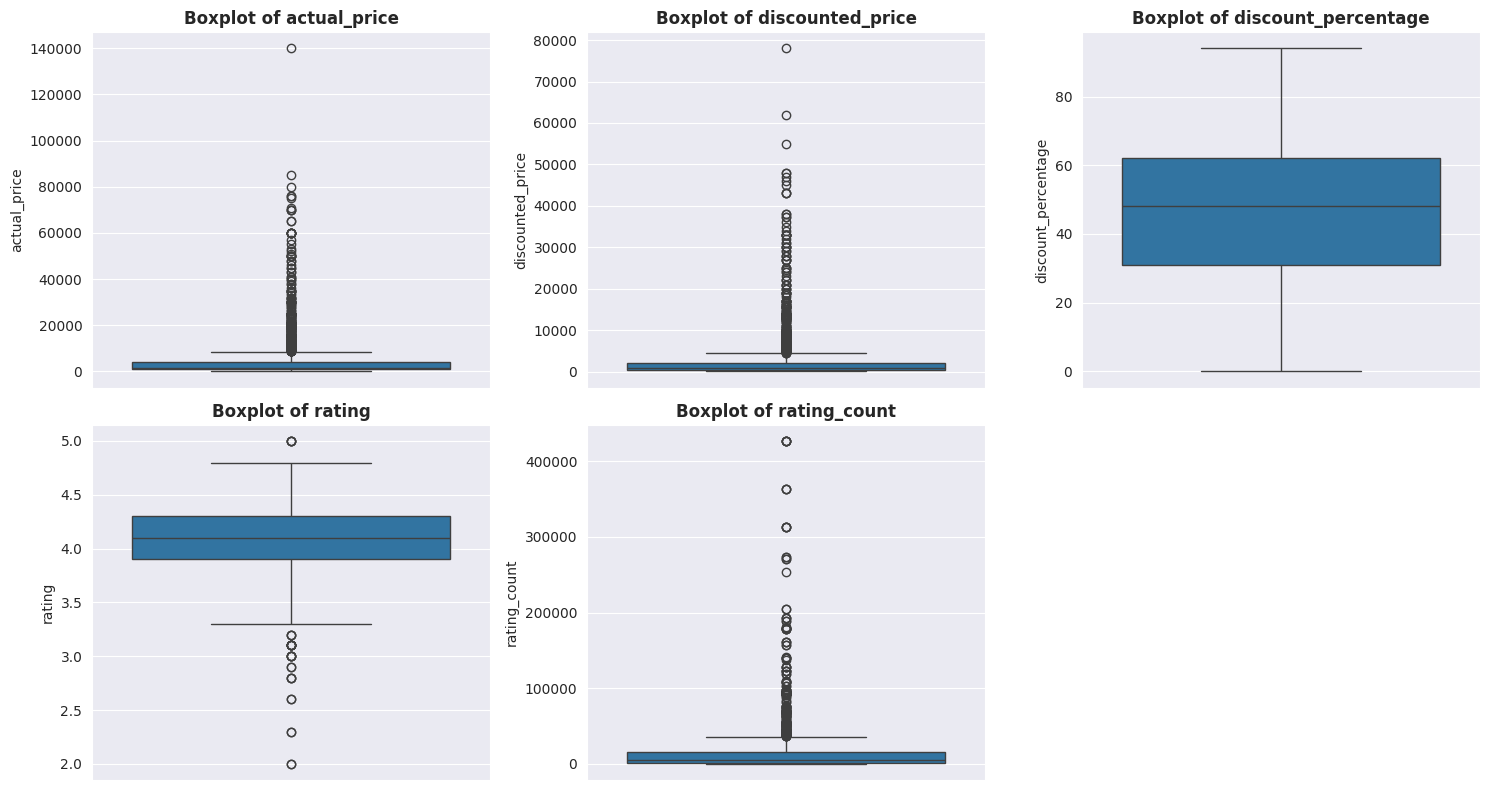

In [ ]:
# Select numerical columns
numerical_columns = [
    "actual_price",
    "discounted_price",
    "discount_percentage",
    "rating",
    "rating_count"
]

# Create boxplots
plt.figure(figsize=(15, 8))

for i, column in enumerate(numerical_columns, 1):

    plt.subplot(2, 3, i)

    sns.boxplot(
        y=df[column]
    )

    plt.title(
        f"Boxplot of {column}",
        fontsize=12,
        fontweight="bold"
    )

    plt.ylabel(column)

plt.tight_layout()

plt.show()

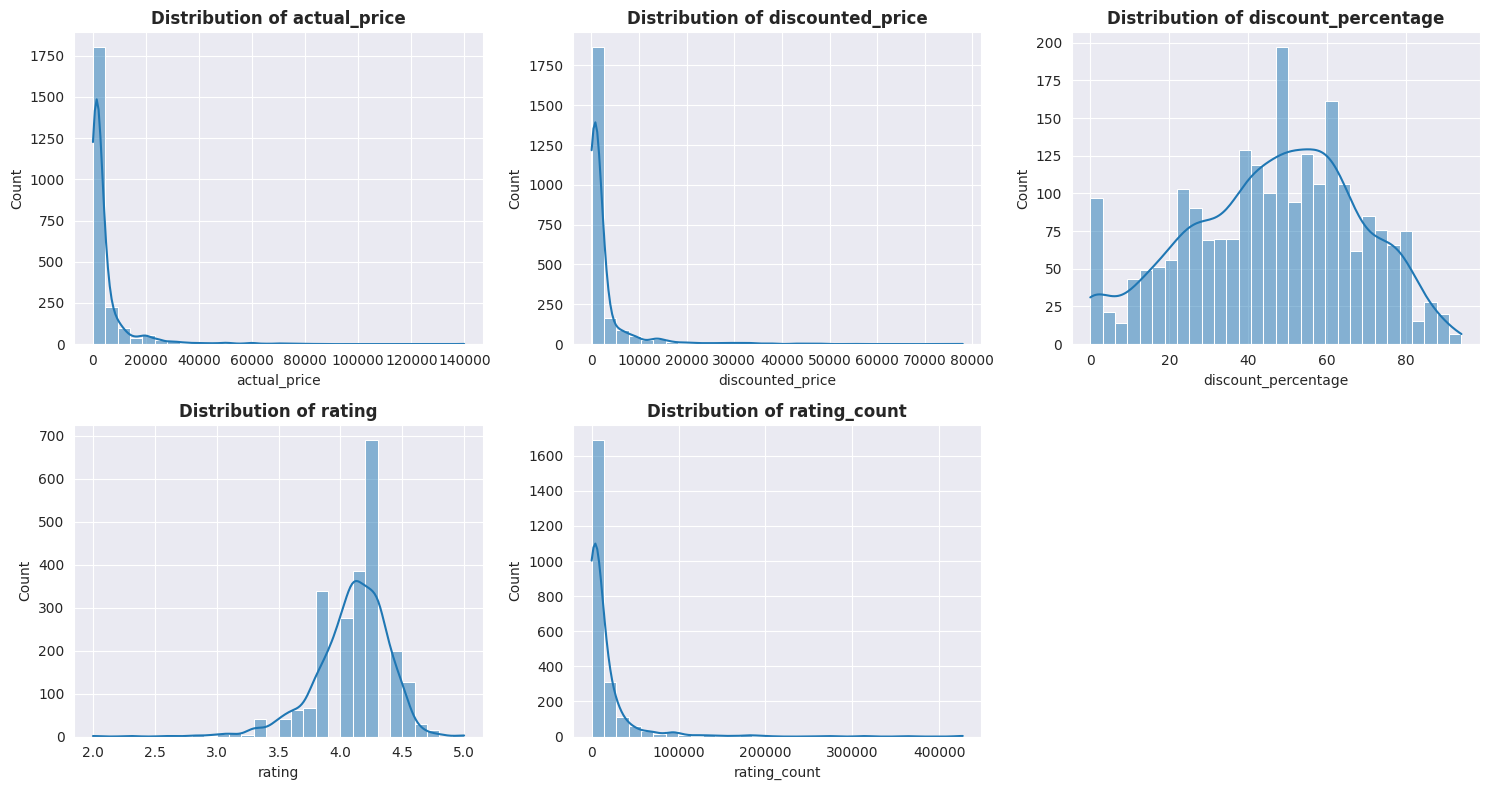

In [ ]:
# Create histograms
plt.figure(figsize=(15, 8))

for i, column in enumerate(numerical_columns, 1):

    plt.subplot(2, 3, i)

    sns.histplot(
        data=df,
        x=column,
        bins=30,
        kde=True
    )

    plt.title(
        f"Distribution of {column}",
        fontsize=12,
        fontweight="bold"
    )

    plt.xlabel(column)

plt.tight_layout()

plt.show()

In [ ]:
numerical_columns = [
    "actual_price",
    "discounted_price",
    "discount_percentage",
    "rating",
    "rating_count"
]

outlier_summary = []

for column in numerical_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = (
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ).sum()

    outlier_percentage = (
        outlier_count / len(df)
    ) * 100

    outlier_summary.append({
        "Column": column,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": outlier_count,
        "Outlier Percentage": outlier_percentage
    })

outlier_summary = pd.DataFrame(outlier_summary)

display(outlier_summary)

,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
0,actual_price,850.0,3999.0,3149.0,-3873.5,8722.5,295,12.798265
1,discounted_price,348.0,1999.0,1651.0,-2128.5,4475.5,296,12.841649
2,discount_percentage,31.0,62.0,31.0,-15.5,108.5,0,0.000000
3,rating,3.9,4.3,0.4,3.3,4.9,31,1.344902
4,rating_count,1173.0,15188.0,14015.0,-19849.5,36210.5,224,9.718004


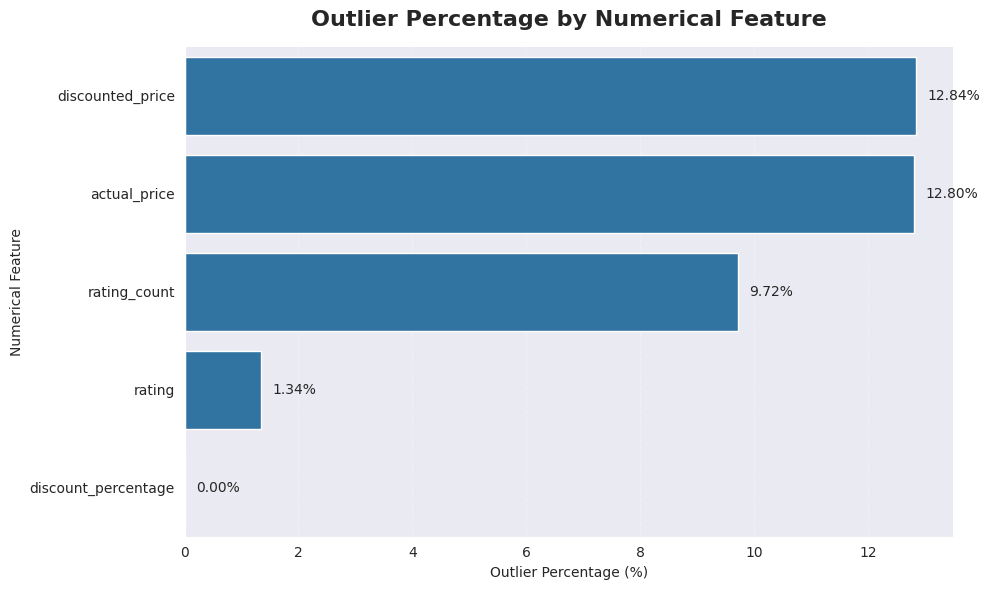

In [ ]:
# Sort columns by outlier percentage
outlier_plot = outlier_summary.sort_values(
    by="Outlier Percentage",
    ascending=False
)

# Create figure
plt.figure(figsize=(10, 6))

# Create bar chart
sns.barplot(
    data=outlier_plot,
    x="Outlier Percentage",
    y="Column"
)

# Add percentage values
for i, value in enumerate(outlier_plot["Outlier Percentage"]):

    plt.text(
        value + 0.2,
        i,
        f"{value:.2f}%",
        va="center"
    )

# Add title and labels
plt.title(
    "Outlier Percentage by Numerical Feature",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Outlier Percentage (%)")
plt.ylabel("Numerical Feature")

# Add grid
plt.grid(axis="x", linestyle="--", alpha=0.3)

# Clean layout
sns.despine()
plt.tight_layout()

plt.show()

In [ ]:
def get_outliers(data, column):

    # Calculate Q1 and Q3
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    # Calculate IQR
    IQR = Q3 - Q1

    # Calculate boundaries
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Return rows outside the boundaries
    outliers = data[
        (data[column] < lower_bound) |
        (data[column] > upper_bound)
    ]

    return outliers

In [ ]:
actual_price_outliers = get_outliers(
    df,
    "actual_price"
)

actual_price_outliers[
    [
        "product_name",
        "main_category",
        "actual_price",
        "discounted_price"
    ]
].sort_values(
    by="actual_price",
    ascending=False
).head(10)

,product_name,main_category,actual_price,discounted_price
249,Sony Bravia 164 cm (65 inches) 4K Ultra HD Sma...,Electronics,139900.0,77990.0
255,VU 164 cm (65 inches) The GloLED Series 4K Sma...,Electronics,85000.0,54990.0
283,LG 139 cm (55 inches) 4K Ultra HD Smart LED TV...,Electronics,79990.0,47990.0
1071,LG 1.5 Ton 5 Star AI DUAL Inverter Split AC (C...,Home&Kitchen,75990.0,42990.0
2197,LG 1.5 Ton 5 Star AI DUAL Inverter Split AC (C...,Home&Kitchen,75990.0,42990.0
1411,"Samsung Galaxy S20 FE 5G (Cloud Navy, 8GB RAM,...",Electronics,74999.0,37990.0
192,Samsung 138 cm (55 inches) Crystal 4K Neo Seri...,Electronics,70900.0,47990.0
332,MI 138.8 cm (55 inches) 5X Series 4K Ultra HD ...,Electronics,69999.0,46999.0
325,OnePlus 163.8 cm (65 inches) U Series 4K LED S...,Electronics,69999.0,61999.0
276,Samsung 138 cm (55 inches) Crystal 4K Series U...,Electronics,69900.0,45999.0


In [ ]:
display(outlier_summary)

,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
0,actual_price,850.0,3999.0,3149.0,-3873.5,8722.5,295,12.798265
1,discounted_price,348.0,1999.0,1651.0,-2128.5,4475.5,296,12.841649
2,discount_percentage,31.0,62.0,31.0,-15.5,108.5,0,0.000000
3,rating,3.9,4.3,0.4,3.3,4.9,31,1.344902
4,rating_count,1173.0,15188.0,14015.0,-19849.5,36210.5,224,9.718004


In [ ]:
# Count completely duplicate rows
duplicate_rows = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_rows)

Number of duplicate rows: 842


In [ ]:
duplicate_rows = df.duplicated().sum()

duplicate_percentage = (
    duplicate_rows / len(df)
) * 100

print("Total Rows:", len(df))
print("Duplicate Rows:", duplicate_rows)
print(f"Duplicate Percentage: {duplicate_percentage:.2f}%")

Total Rows: 2305
Duplicate Rows: 842
Duplicate Percentage: 36.53%


In [ ]:
duplicate_data = df[df.duplicated()]
display(duplicate_data.head(10))

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link,main_category
1465,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,199.0,349.0,43.0,4.0,43994.0,"Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...,Computers&Accessories
1466,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,199.0,999.0,80.0,3.9,7928.0,【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...,Computers&Accessories
1467,B09ZQK9X8G,Noise ColorFit Pro 4 Advanced Bluetooth Callin...,Electronics|WearableTechnology|SmartWatches,2998.0,5999.0,50.0,4.1,5179.0,Advanced Bluetooth calling: Upgrade to an effo...,"AEL5HU25IP7YT5WK3LXNC5M36NBA,AG6OO5TADBKM6RSXL...","Sanjay G.,Vinay Bucha,Amazon Customer,arun,Roh...","R14ALM4LONM07K,RBQ5KLENMT5W,RC8LE1R8ZUXK6,R2DO...","Some improvement required,Not best for trackin...",1. Please add app gallery when we do right to ...,https://m.media-amazon.com/images/I/413x7j3Z30...,https://www.amazon.in/Noise-ColorFit-Bluetooth...,Electronics
1468,B08ZJDWTJ1,Seagate Expansion 1TB External HDD - USB 3.0 f...,Computers&Accessories|ExternalDevices&DataStor...,4098.0,4999.0,18.0,4.5,50810.0,Digital Storage Capacity - 1TB; Get an extra l...,"AFWREBMJRX47V7TJD5E7VUBKZY3Q,AFKUWB5DABB7DVVRN...","Pallavi Varur,Amitasap,PRADEEP,Karma,JASWANTSI...","R2BYIBOB1SJCU5,R27XI4KBBS4CO0,RNDLXV8UJZSO,R1H...","Good,gud,Hard disk,Good product,Serve the purp...","Good one.,gud,Hard disk is good but data cable...",https://m.media-amazon.com/images/I/41igriVLab...,https://www.amazon.in/Seagate-Expansion-1TB-Ex...,Computers&Accessories
1469,B08FTFXNNB,HP w100 480P 30 FPS Digital Webcam with Built-...,Electronics|Cameras&Photography|VideoCameras,499.0,1999.0,75.0,3.7,3369.0,HP w100 480P HD Web Camera enables the user to...,"AHLLRY3ISUM56WO2EJYCDE4J6E3Q,AGL2WQUXIVJ7MJZO2...","IC,neetu singh,Prasenjit Jana,DANGAR RAMABEN K...","RXPIU94G6Y8XR,RG8WXHVO3Q5BN,R2VKT81SI4UN3S,R1T...","Value for money, good wuality,Reliable and eas...","The video is slight zoomed in, which is great ...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/HP-Webcam-Wide-Angle-Cal...,Electronics
1470,B08YDFX7Y1,ZEBRONICS Zeb-Dash Plus 2.4GHz High Precision ...,Computers&Accessories|Accessories&Peripherals|...,299.0,449.0,33.0,3.5,11827.0,DESIGN: Wireless Mouse with Ergonomic form fac...,"AFJ7UDS63R5ITGAMOSRK7KNWHSSA,AH7ZV5NZPWUYLZQLP...","Wilson Patel,Sneha m,Karthikeyan G,Karnal kuma...","RLR4ETD7RIB3P,R2TLZ8IYTYAIJR,R3C4LR2YHIRZ95,R3...","Useful for simple use,Great product,Good,Good ...",I have used it for week now on daily basis. It...,https://m.media-amazon.com/images/I/31HWJqJdtj...,https://www.amazon.in/ZEBRONICS-Zeb-Dash-Wirel...,Computers&Accessories
1471,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,329.0,699.0,53.0,4.2,94364.0,The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good prod

In [ ]:
print("Duplicate Product IDs:", df["product_id"].duplicated().sum())

print("Duplicate Review IDs:", df["review_id"].duplicated().sum())

Duplicate Product IDs: 956
Duplicate Review IDs: 1112


In [ ]:
# Check how many unique values exist

print("Total Rows:", len(df))

print("Unique Product IDs:", df["product_id"].nunique())

print("Unique Review IDs:", df["review_id"].nunique())

print("Unique User IDs:", df["user_id"].nunique())

Total Rows: 2305
Unique Product IDs: 1349
Unique Review IDs: 1193
Unique User IDs: 1193


In [ ]:
# Show all rows having duplicate review IDs

duplicate_reviews_data = df[
    df["review_id"].duplicated(keep=False)
]

display(
    duplicate_reviews_data[
        [
            "product_id",
            "product_name",
            "user_id",
            "user_name",
            "review_id",
            "rating",
            "review_title"
        ]
    ].head(20)
)

,product_id,product_name,user_id,user_name,review_id,rating,review_title
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...",4.2,"Satisfied,Charging is really fast,Value for mo..."
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,"AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...",4.0,"A Good Braided Cable for Your Type C Device,Go..."
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...",3.9,"Good speed for earlier versions,Good Product,W..."
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...",4.2,"Good product,Good one,Nice,Really nice product..."
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...",4.2,"As good as original,Decent,Good one for second..."
5,B08Y1TFSP6,pTron Solero TB301 3A Type-C Data and Fast Cha...,"AEQ2YMXSZWEOHK2EHTNLOS56YTZQ,AGRVINWECNY7323CW...","Jayesh,Rajesh k.,Soopy,amazon customer,Aman,Sh...","R7S8ANNSDPR40,R3CLZFLHVJU26P,RFF7U7MPQFUGR,R1M...",3.9,"It's pretty good,Average quality,very good and..."
6,B08WRWPM22,"boAt Micro USB 55 Tangle-free, Sturdy Micro US...","AG7C6DAADCTRQJG2BRS3RIKDT52Q,AFU7BOMPVJ7Q3TTA4...","Vivek kumar,Amazon Customer,SARTHAK,Chiranjeev...","R8E73K2KWJRDS,RSD0JTIIWQQL8,R64CRSTE9SLW1,R2FR...",4.1,"Long durable.,good,Does not charge Lenovo m8 t..."
7,B08DDRGWTJ,MI Usb Type-C Cable Smartphone (Black),"AHW6E5LQ2BDYOIVLAJGDH45J5V5Q,AF74RSGCHPZITVFSZ...","Pavan A H,Jayesh bagad,Shridhar,rajendran,karu...","R2X090D1YHACKR,R32ZCIH9AFNJ60,R3N57EVVG0EHAF,R...",4.3,"Worth for money - suitable for Android auto,Go..."
8,B008IFXQFU,"TP-Link USB WiFi Adapter for PC(TL-WN725N), N1...","AGV3IEFANZCKECFGUM42MRH5FNOA,AEBO7NWCNXKT4AESA...","Azhar JuMan,Anirudh Sood,Hari Krishnan PS,Akas...","R1LW6NWSVTVZ2H,R3VR5WFKUS15C5,R2F6GC79OYWUKQ,R...",4.2,Works on linux for me. Get the model with ante...
9,B082LZGK39,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,"AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...",4.0,"A Good Braided Cable for Your Type C Device,Go..."


In [ ]:
# Create a copy of the original dataset
df_clean = df.copy()
df_clean.drop_duplicates(inplace=True)
important_columns = [
    "product_id",
    "product_name",
    "category",
    "discounted_price",
    "actual_price",
    "discount_percentage",
    "rating"
]

df_clean.dropna(
    subset=important_columns,
    inplace=True
)


df_clean = df_clean[
    (df_clean["actual_price"] > 0) &
    (df_clean["discounted_price"] > 0)
]


df_clean = df_clean[
    df_clean["discounted_price"] <= df_clean["actual_price"]
]

df_clean = df_clean[
    (df_clean["rating"] >= 0) &
    (df_clean["rating"] <= 5)
]


df_clean = df_clean[
    (df_clean["discount_percentage"] >= 0) &
    (df_clean["discount_percentage"] <= 100)
]


df_clean["main_category"] = (
    df_clean["category"]
    .str.split("|")
    .str[0]
    .str.strip()
)


df_clean["savings_amount"] = (
    df_clean["actual_price"] -
    df_clean["discounted_price"]
)


df_clean.reset_index(
    drop=True,
    inplace=True
)


print("Original Dataset Shape:", df.shape)
print("Cleaned Dataset Shape:", df_clean.shape)

print("\nRemaining Missing Values:")
print(df_clean.isnull().sum())

print("\nDuplicate Rows:")
print(df_clean.duplicated().sum())

print("\nFinal Data Types:")
print(df_clean.dtypes)

Original Dataset Shape: (2305, 17)
Cleaned Dataset Shape: (1463, 18)

Remaining Missing Values:
product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           0
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
main_category          0
savings_amount         0
dtype: int64

Duplicate Rows:
0

Final Data Types:
product_id              object
product_name            object
category                object
discounted_price       float64
actual_price           float64
discount_percentage    float64
rating                 float64
rating_count           float64
about_product           object
user_id                 object
user_name               object
review_id               object
review_title            object


In [ ]:
# Basic information about cleaned dataset

print("Cleaned Dataset Shape:")
print(df_clean.shape)

print("\nMissing Values:")
print(df_clean.isnull().sum())

print("\nDuplicate Rows:")
print(df_clean.duplicated().sum())

Cleaned Dataset Shape:
(1463, 18)

Missing Values:
product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           0
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
main_category          0
savings_amount         0
dtype: int64

Duplicate Rows:
0
